In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/imdb_features.csv")

model = joblib.load("../models/movie_rating_xgb_model.pkl")
model_features = joblib.load("../models/model_features.pkl")

print("Dataset shape:", df.shape)
print("Number of model features:", len(model_features))

Dataset shape: (7919, 72)
Number of model features: 63


In [3]:
drop_cols = [
    "name", "genre", "main_genre", "director",
    "actor_1", "actor_2", "actor_3", "runtime_category"
]

df_model = df.drop(columns=drop_cols, errors="ignore")

X = df_model.drop("rating", axis=1)
y = df_model["rating"]

X = X[model_features]

display(X.head())

,year,duration,votes,duration_missing,votes_missing,year_missing,director_missing,actor_1_missing,movie_age,genre_count,...,genre_horror.1,genre_music.1,genre_musical.1,genre_mystery.1,genre_romance.1,genre_sci-fi.1,genre_sport.1,genre_thriller.1,genre_unknown,genre_war.1
0,2019.0,109.0,8.0,0,0,0,0,0,7.0,1,...,0,0,0,0,0,0,0,0,0,0
1,2019.0,110.0,35.0,0,0,0,0,0,7.0,2,...,0,0,0,0,0,0,0,0,0,0
2,1997.0,147.0,827.0,0,0,0,0,0,29.0,3,...,0,0,0,0,0,0,0,0,0,0
3,2005.0,142.0,1086.0,0,0,0,0,0,21.0,3,...,0,0,0,0,0,0,0,0,0,0
4,2012.0,82.0,326.0,0,0,0,0,0,14.0,3,...,1,0,0,0,0,0,0,0,0,0


In [4]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

print("SHAP values generated successfully!")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values generated successfully!
SHAP values shape: (7919, 63)


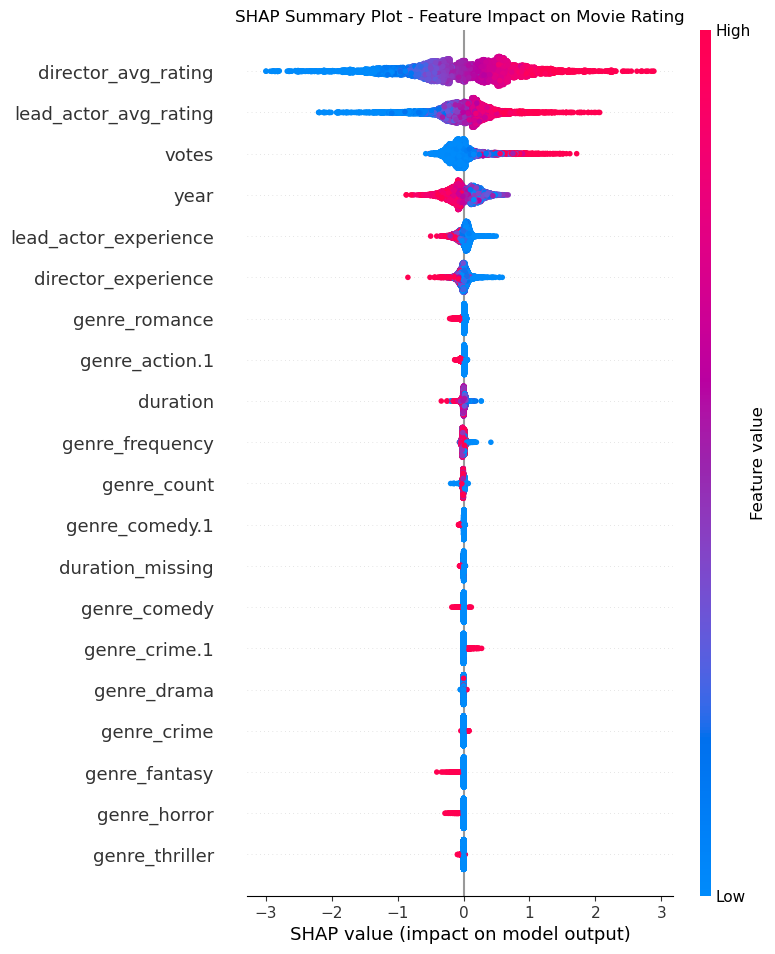

In [5]:
shap.summary_plot(shap_values, X, show=False)

plt.title("SHAP Summary Plot - Feature Impact on Movie Rating")
plt.show()

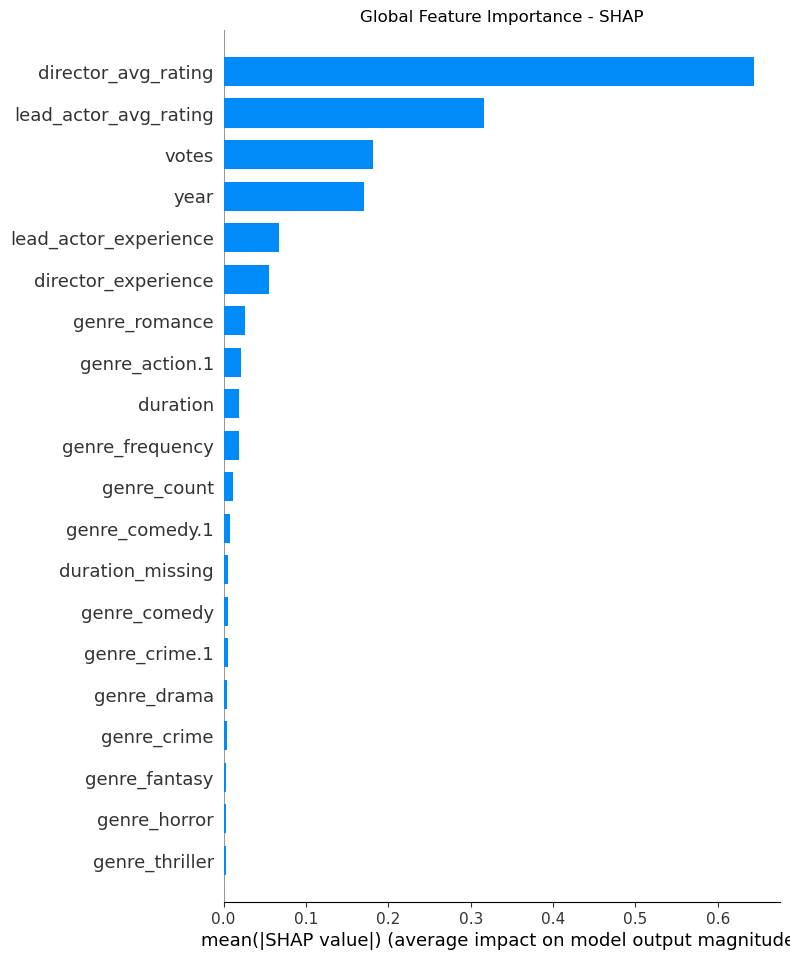

In [6]:
shap.summary_plot(shap_values, X, plot_type="bar", show=False)

plt.title("Global Feature Importance - SHAP")
plt.show()

In [7]:
shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean Absolute SHAP Value": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean Absolute SHAP Value", ascending=False)

display(shap_importance.head(20))

,Feature,Mean Absolute SHAP Value
15,director_avg_rating,0.643329
17,lead_actor_avg_rating,0.316524
2,votes,0.181047
0,year,0.170853
16,lead_actor_experience,0.067221
14,director_experience,0.054921
36,genre_romance,0.026195
42,genre_action.1,0.021224
1,duration,0.018914
18,genre_frequency,0.018469


In [8]:
shap_importance.to_csv("../models/shap_feature_importance.csv", index=False)

print("SHAP feature importance saved successfully!")

SHAP feature importance saved successfully!


In [9]:
sample_index = 0

movie_name = df.iloc[sample_index]["name"]
actual_rating = y.iloc[sample_index]
predicted_rating = model.predict(X.iloc[[sample_index]])[0]

print("Movie:", movie_name)
print("Actual Rating:", actual_rating)
print("Predicted Rating:", round(predicted_rating, 2))

Movie: #Gadhvi (He thought he was Gandhi)
Actual Rating: 7.0
Predicted Rating: 7.12


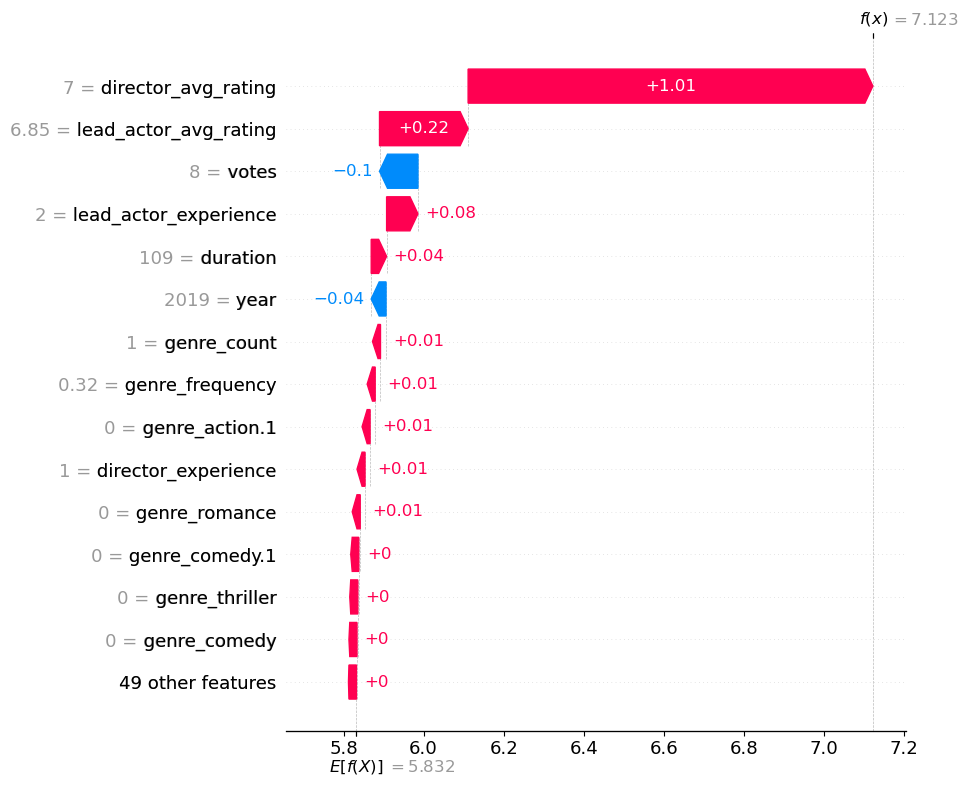

In [10]:
shap_explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X.iloc[sample_index],
    feature_names=X.columns
)

shap.plots.waterfall(shap_explanation, max_display=15)

In [11]:
local_shap = pd.DataFrame({
    "Feature": X.columns,
    "Feature Value": X.iloc[sample_index].values,
    "SHAP Contribution": shap_values[sample_index]
}).sort_values("SHAP Contribution", ascending=False)

print("Top Positive Contributions")
display(local_shap.head(10))

print("Top Negative Contributions")
display(local_shap.tail(10))

Top Positive Contributions


,Feature,Feature Value,SHAP Contribution
15,director_avg_rating,7.0,1.011557
17,lead_actor_avg_rating,6.85,0.221434
16,lead_actor_experience,2,0.078319
1,duration,109.0,0.038498
9,genre_count,1,0.013903
18,genre_frequency,0.319737,0.013266
42,genre_action.1,0,0.012715
14,director_experience,1,0.012656
36,genre_romance,0,0.012013
46,genre_comedy.1,0,0.003636


Top Negative Contributions


,Feature,Feature Value,SHAP Contribution
12,highly_popular_movie,0,-0.000180
51,genre_fantasy.1,0,-0.000398
24,genre_biography,0,-0.000550
30,genre_history,0,-0.000617
27,genre_drama,0,-0.000714
26,genre_crime,0,-0.000909
28,genre_family,0,-0.000909
47,genre_crime.1,0,-0.001053
0,year,2019.0,-0.037075
2,votes,8.0,-0.096059


In [12]:
def explain_prediction(local_shap_df, predicted_rating):
    positive = local_shap_df.sort_values("SHAP Contribution", ascending=False).head(3)
    negative = local_shap_df.sort_values("SHAP Contribution").head(3)

    print(f"Predicted Rating: {predicted_rating:.2f} ⭐")
    print("\nMain reasons increasing the rating:")

    for _, row in positive.iterrows():
        print(f"• {row['Feature']} contributed +{row['SHAP Contribution']:.3f}")

    print("\nMain reasons decreasing the rating:")

    for _, row in negative.iterrows():
        print(f"• {row['Feature']} contributed {row['SHAP Contribution']:.3f}")

explain_prediction(local_shap, predicted_rating)

Predicted Rating: 7.12 ⭐

Main reasons increasing the rating:
• director_avg_rating contributed +1.012
• lead_actor_avg_rating contributed +0.221
• lead_actor_experience contributed +0.078

Main reasons decreasing the rating:
• votes contributed -0.096
• year contributed -0.037
• genre_crime.1 contributed -0.001


Most important feature: director_avg_rating


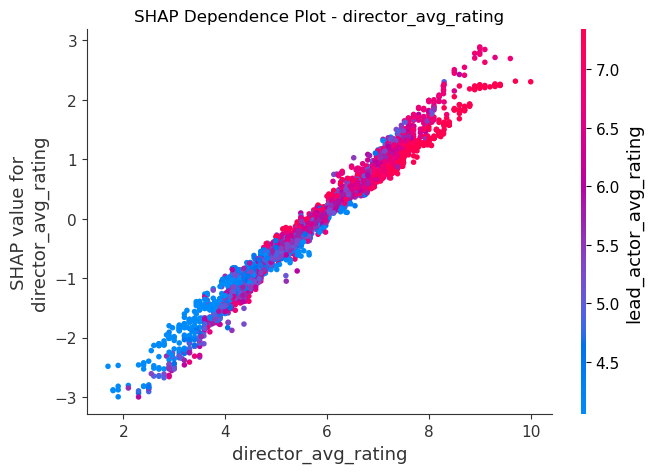

In [13]:
top_feature = shap_importance.iloc[0]["Feature"]

print("Most important feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X,
    show=False
)

plt.title(f"SHAP Dependence Plot - {top_feature}")
plt.show()

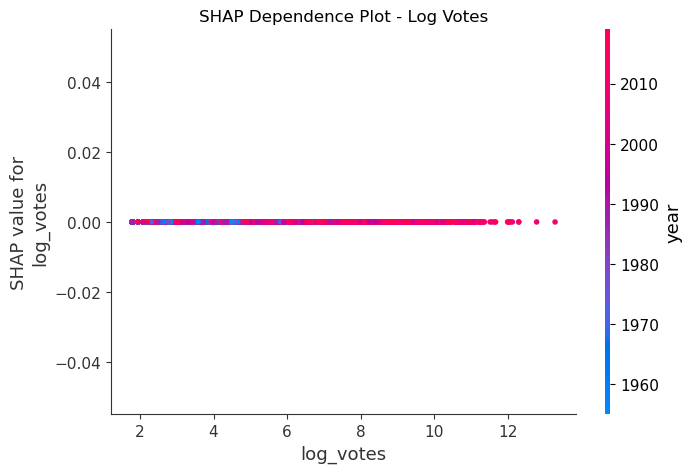

In [14]:
if "log_votes" in X.columns:
    shap.dependence_plot(
        "log_votes",
        shap_values,
        X,
        show=False
    )

    plt.title("SHAP Dependence Plot - Log Votes")
    plt.show()
else:
    print("log_votes not found in features.")

In [15]:
sample_movies = df.sample(5, random_state=42).index

for idx in sample_movies:
    movie_name = df.loc[idx, "name"]
    actual = y.loc[idx]
    pred = model.predict(X.loc[[idx]])[0]

    local_df = pd.DataFrame({
        "Feature": X.columns,
        "Feature Value": X.loc[idx].values,
        "SHAP Contribution": shap_values[list(X.index).index(idx)]
    }).sort_values("SHAP Contribution", ascending=False)

    print("=" * 70)
    print("Movie:", movie_name)
    print("Actual Rating:", actual)
    print("Predicted Rating:", round(pred, 2))

    print("\nTop factors increasing prediction:")
    display(local_df.head(5))

    print("\nTop factors decreasing prediction:")
    display(local_df.tail(5))

Movie: Mohabbat Pehli Nazar Mein
Actual Rating: 3.3
Predicted Rating: 3.38

Top factors increasing prediction:


,Feature,Feature Value,SHAP Contribution
14,director_experience,1,0.139890
16,lead_actor_experience,4,0.051963
0,year,1991.0,0.018903
57,genre_romance.1,1,0.014970
36,genre_romance,0,0.008911



Top factors decreasing prediction:


,Feature,Feature Value,SHAP Contribution
25,genre_comedy,0,-0.006237
18,genre_frequency,0.035232,-0.007437
2,votes,6.0,-0.141786
17,lead_actor_avg_rating,3.525,-0.572380
15,director_avg_rating,3.3,-1.965012


Movie: Veerappan
Actual Rating: 5.3
Predicted Rating: 4.86

Top factors increasing prediction:


...

,Feature,Feature Value,SHAP Contribution
47,genre_crime.1,0,-0.008485
16,lead_actor_experience,22,-0.059735
2,votes,242.0,-0.124415
0,year,2003.0,-0.174237
15,director_avg_rating,4.98,-0.483554


Movie: Horror Night
Actual Rating: 3.5
Predicted Rating: 3.45

Top factors increasing prediction:


,Feature,Feature Value,SHAP Contribution
14,director_experience,1,0.141668
16,lead_actor_experience,1,0.061302
9,genre_count,1,0.010125
1,duration,115.0,0.009242
36,genre_romance,0,0.008212



Top factors decreasing prediction:


,Feature,Feature Value,SHAP Contribution
53,genre_horror.1,1,-0.012639
0,year,2017.0,-0.060074
2,votes,11.0,-0.071212
17,lead_actor_avg_rating,3.5,-0.740816
15,director_avg_rating,3.5,-1.728536


In [16]:
local_shap.to_csv("../models/sample_movie_shap_explanation.csv", index=False)

print("Local SHAP explanation saved successfully!")

Local SHAP explanation saved successfully!


In [17]:
print("=" * 70)
print("SHAP EXPLAINABILITY SUMMARY")
print("=" * 70)

print("\nTop 10 Features Influencing Movie Rating:")
for i, row in shap_importance.head(10).iterrows():
    print(f"• {row['Feature']}")

print("\nInterpretation:")
print("SHAP helps explain how each feature pushes the predicted movie rating higher or lower.")
print("This makes the model more transparent and easier to interpret for recruiters, users, and stakeholders.")

SHAP EXPLAINABILITY SUMMARY

Top 10 Features Influencing Movie Rating:
• director_avg_rating
• lead_actor_avg_rating
• votes
• year
• lead_actor_experience
• director_experience
• genre_romance
• genre_action.1
• duration
• genre_frequency

Interpretation:
SHAP helps explain how each feature pushes the predicted movie rating higher or lower.
This makes the model more transparent and easier to interpret for recruiters, users, and stakeholders.
